In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [8]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [15]:
df = pd.read_csv("/content/drive/MyDrive/SAA/data_folder/mtcars.csv")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   model   32 non-null     object 
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), object(1)
memory usage: 3.1+ KB


In [ ]:
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [16]:
from sklearn.preprocessing import LabelEncoder

le= LabelEncoder()
df['Class']= le.fit_transform(df['model'])

In [ ]:
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,Class
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4,17
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4,18
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1,4
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1,12
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2,13


In [17]:
# Vamos a ver qué atributos son los más importantes
from sklearn.linear_model import LassoCV

X= df.iloc[:,1:12]
y= df.iloc[:,-1]

In [12]:
reg = LassoCV()
reg.fit(X, y)
coef = pd.Series(reg.coef_, index = X.columns)

Text(0.5, 1.0, 'Importancia de las variables usando el Modelo de Lasso')

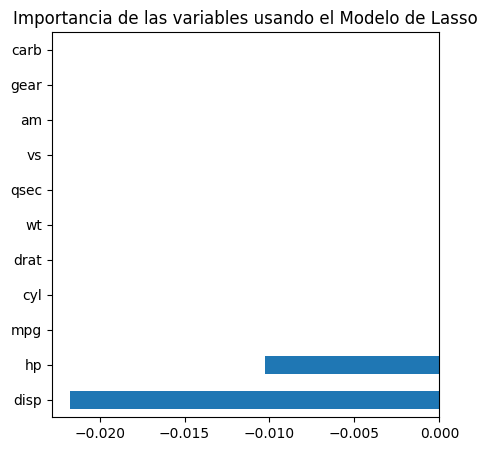

In [13]:
imp_coef = coef.sort_values()
plt.rcParams['figure.figsize'] = (5, 5)
imp_coef.plot(kind = "barh")
plt.title("Importancia de las variables usando el Modelo de Lasso")

In [ ]:
X=df[['disp','hp']]

In [ ]:
# Vamos a ver cuántos clústeres necesitamos
from sklearn.cluster import KMeans

# usando el método del codo
# WCSS (Within Cluster Sum of Squares) es la suma de la distancia al cuadrado entre cada punto y el centroide de un grupo
wcss=[]
for i in range(1,7):
    kmeans= KMeans(n_clusters=i, init='k-means++', random_state=1)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

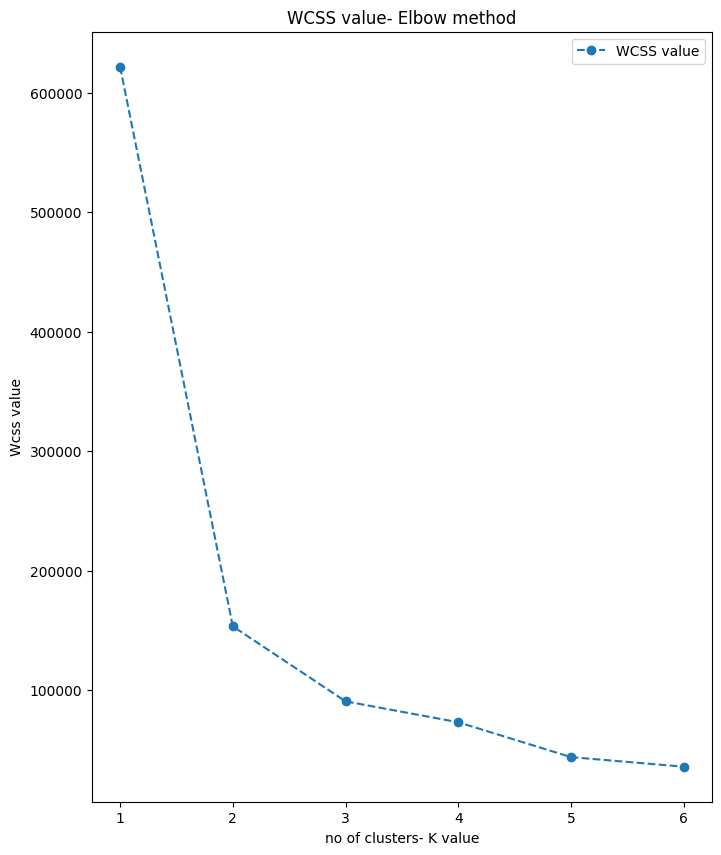

In [ ]:
plt.plot(range(1,7), wcss, linestyle='--', marker='o', label='WCSS value')
plt.title('WCSS value- Elbow method')
plt.xlabel('no of clusters- K value')
plt.ylabel('Wcss value')
plt.legend()
plt.show()

In [ ]:
# Por lo tanto tenemos dos clusters
kmeans= KMeans(n_clusters=2, random_state=1)
kmeans.fit(X)

KMeans(n_clusters=2, random_state=1)

In [ ]:
df['cluster']=kmeans.predict(X)
df.sort_values(by='cluster').head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb,Class,cluster
15,Lincoln Continental,10.4,8,460.0,215,3.00,5.424,17.82,0,0,3,4,14,0
22,AMC Javelin,15.2,8,304.0,150,3.15,3.435,17.30,0,0,3,2,0,0
16,Chrysler Imperial,14.7,8,440.0,230,3.23,5.345,17.42,0,0,3,4,3,0
30,Maserati Bora,15.0,8,301.0,335,3.54,3.570,14.60,0,1,5,8,16,0
14,Cadillac Fleetwood,10.4,8,472.0,205,2.93,5.250,17.98,0,0,3,4,1,0


In [ ]:
kmeans.cluster_centers_

array([[346.76      , 202.6       ],
       [128.33529412,  97.35294118]])

Text(0.5, 0, 'disp')

Text(0, 0.5, 'hp')

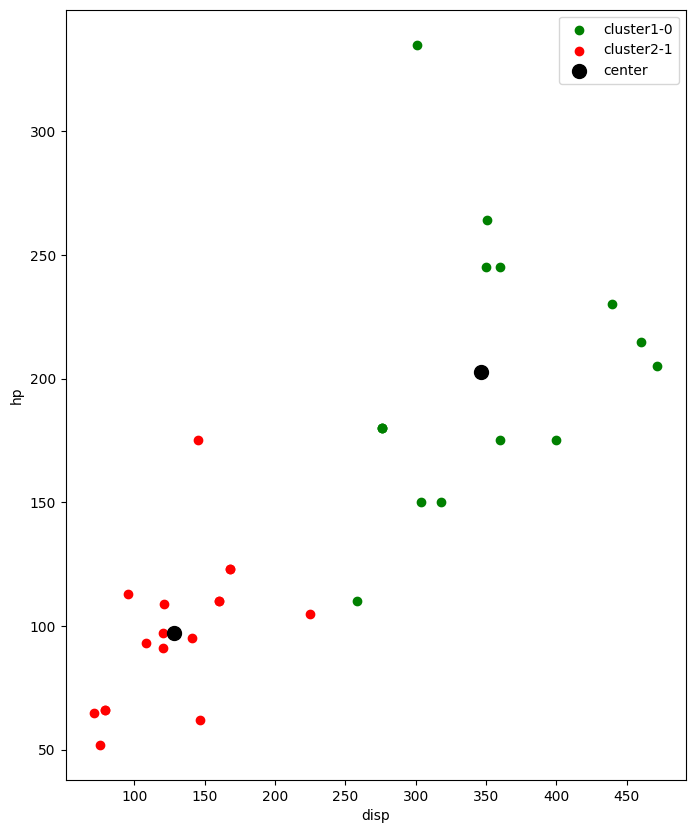

In [ ]:
# Para visualizarlo
plt.scatter(df.loc[df['cluster']==0]['disp'], df.loc[df['cluster']==0]['hp'], c='green', label='cluster1-0')
plt.scatter(df.loc[df['cluster']==1]['disp'], df.loc[df['cluster']==1]['hp'], c='red', label='cluster2-1')
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='black', label='center')
plt.xlabel('disp')
plt.ylabel('hp')
plt.legend()
plt.show()